In [707]:
import kagglehub
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [708]:
path = kagglehub.dataset_download("julienjta/twitter-mentions-volumes")

print(os.listdir(path))

['dataset.csv']


In [709]:
file_path = os.path.join(path, 'dataset.csv')

# Load the CSV file into a pandas DataFrame
df = pd.read_csv(file_path)

In [710]:
df

,timestamp,Apple,Amazon,Salesforce,CVS,Facebook,Google,IBM,Coca-Cola,Pfizer,UPS
0,2015-02-26 21:42:53,104,57.0,11,0.0,53.0,35.0,7.0,8.0,3.0,2.0
1,2015-02-26 21:47:53,100,43.0,10,0.0,64.0,41.0,4.0,8.0,2.0,2.0
2,2015-02-26 21:52:53,99,55.0,3,0.0,49.0,32.0,14.0,5.0,2.0,4.0
3,2015-02-26 21:57:53,154,64.0,4,0.0,48.0,36.0,6.0,13.0,36.0,3.0
4,2015-02-26 22:02:53,120,93.0,9,0.0,22.0,32.0,1.0,22.0,8.0,5.0
...,...,...,...,...,...,...,...,...,...,...,...
15897,2015-04-23 02:27:53,44,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
15898,2015-04-23 02:32:53,45,NaN,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
15899,2015-04-23 02:37:53,48,NaN,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
15900,2015-04-23 02:42:53,26,NaN,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [711]:
df['timestamp'] = pd.to_datetime(df['timestamp'])

In [712]:
df = df.dropna() #we have so plenty of data we could just drop or use only apple and salesforce

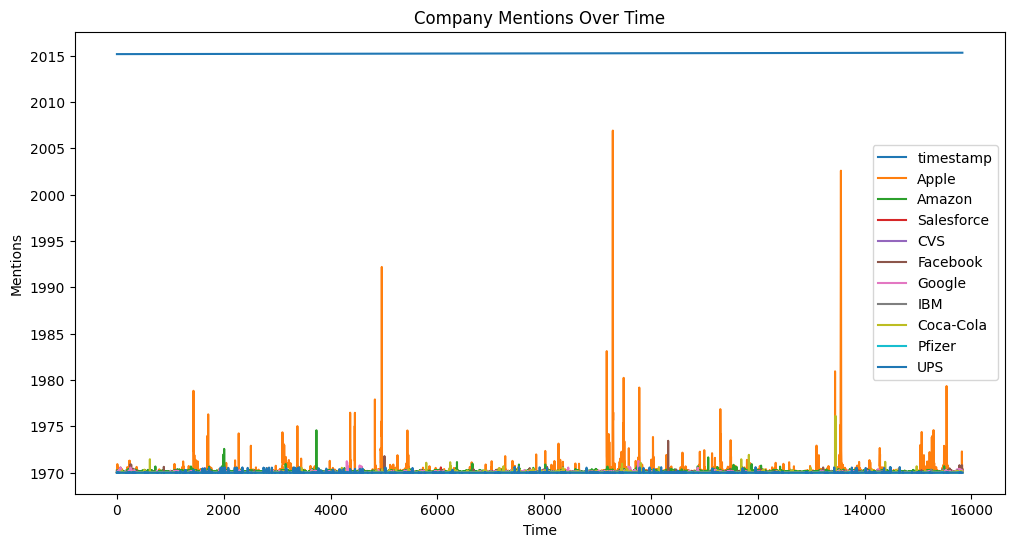

In [713]:
import matplotlib.pyplot as plt

df.plot(figsize=(12,6))
plt.title("Company Mentions Over Time")
plt.xlabel("Time")
plt.ylabel("Mentions")
plt.show()

In [8]:
df = df.set_index('timestamp')

In [9]:
n = len(df)
train_end = int(0.7 * n)
val_end = int(0.85 * n)

print(n, train_end, val_end)

15831 11081 13456


In [10]:
train = df.iloc[:train_end]
val = df.iloc[train_end:val_end]
test = df.iloc[val_end:]

In [714]:
from sklearn.preprocessing import StandardScaler

def scale_data(df):
    df = np.log1p(df)

    window_size = 12
    df_detrended = df - df.rolling(window_size).mean()
    df_detrended = df_detrended.dropna()

    scaled = StandardScaler().fit_transform(df)

    scaled_df = pd.DataFrame(
    scaled,
    columns=df.columns,
    index=df.index
    )

    return df_detrended

In [636]:
train_scaled = scale_data(train)
train_scaled

,Apple,Amazon,Salesforce,CVS,Facebook,Google,IBM,Coca-Cola,Pfizer,UPS
timestamp,,,,,,,,,,
2015-02-26 22:37:53,0.136774,-0.107436,0.053109,-0.115525,-0.010621,-0.124834,-0.132332,-0.008461,-0.603973,0.072862
2015-02-26 22:42:53,0.315001,0.049193,0.098025,0.519860,0.417407,-0.010590,-0.121205,0.426253,-0.546211,-0.586497
2015-02-26 22:47:53,0.553192,0.077335,-0.640999,-0.173287,0.240226,0.043820,0.344836,-0.266894,-0.512422,0.454353
2015-02-26 22:52:53,0.123119,0.058999,-0.617025,-0.173287,0.087627,0.227724,0.099723,-0.408651,-0.478634,0.272032
2015-02-26 22:57:53,-0.044751,-0.005763,0.529185,-0.173287,0.214862,0.149965,0.483793,0.009660,-0.235486,0.561869
...,...,...,...,...,...,...,...,...,...,...
2015-04-06 08:42:53,-0.385240,-0.482146,0.765068,0.000000,-0.229545,0.196174,-0.783386,-0.082266,0.519860,0.288811
2015-04-06 08:47:53,-0.405915,-0.408349,-0.529676,0.000000,0.422246,-1.098570,0.315226,0.124029,-0.115525,0.288811
2015-04-06 08:52:53,-0.045174,-0.759993,0.163472,0.000000,-0.086519,-0.308582,-0.783386,0.148002,-0.115525,0.288811


In [637]:
val_scaled = scale_data(val)
val_scaled

,Apple,Amazon,Salesforce,CVS,Facebook,Google,IBM,Coca-Cola,Pfizer,UPS
timestamp,,,,,,,,,,
2015-04-06 10:02:53,0.410360,0.014382,0.683332,-0.173287,0.043686,-0.336157,2.705548,0.092492,-0.149313,-0.481729
2015-04-06 10:07:53,0.016978,-0.209442,0.772356,-0.173287,-1.052013,-0.059602,0.378425,0.605473,-0.149313,-0.423966
2015-04-06 10:12:53,-0.266083,-0.354645,0.805364,-0.173287,0.012810,-0.313495,0.074961,0.250406,-0.149313,-0.423966
2015-04-06 10:17:53,-0.085508,-0.370730,0.078428,-0.173287,0.109391,-0.262984,1.208134,0.417534,-0.149313,0.302970
2015-04-06 10:22:53,0.176856,0.064938,0.512896,-0.173287,0.090795,0.159204,-0.829328,0.995157,0.486072,-0.390178
...,...,...,...,...,...,...,...,...,...,...
2015-04-14 14:37:53,0.808194,-0.404051,0.688530,-0.173287,-0.006862,0.537620,0.394918,0.004590,-0.619250,-0.527699
2015-04-14 14:42:53,0.217071,-0.332142,0.303816,0.949299,-0.464080,0.431174,0.816921,0.021893,-0.485130,-0.098261
2015-04-14 14:47:53,-0.019858,-0.163354,0.115877,-0.149313,0.109857,-0.183742,0.261179,2.459202,-0.055692,-1.047560


In [638]:
test_scaled = scale_data(test)
test_scaled

,Apple,Amazon,Salesforce,CVS,Facebook,Google,IBM,Coca-Cola,Pfizer,UPS
timestamp,,,,,,,,,,
2015-04-14 15:57:53,0.273919,0.063528,0.652060,-0.438125,0.318791,0.086870,0.445777,0.352074,-1.383006,-0.037097
2015-04-14 16:02:53,-0.088767,0.016406,0.468112,-0.438125,-0.244897,-0.251203,0.288755,0.153278,-0.284393,-0.986396
2015-04-14 16:07:53,-0.000247,-0.000897,0.047453,-0.438125,-0.168464,-0.269663,0.572188,-0.377350,0.003289,-0.870871
2015-04-14 16:12:53,0.150916,-0.099438,-0.381985,-0.380362,-0.346883,-0.097200,-0.266272,-0.452067,-1.248886,-0.235486
2015-04-14 16:17:53,0.132981,-0.204611,-0.611905,-0.380362,0.351746,-0.139874,-0.520165,0.031136,-0.479381,0.912880
...,...,...,...,...,...,...,...,...,...,...
2015-04-22 20:32:53,-0.533427,-0.085566,0.083078,-0.231049,0.005345,-0.094821,-0.848149,-0.338815,-0.947229,0.232865
2015-04-22 20:37:53,-0.407659,-0.019493,0.231611,-0.231049,-0.141360,-0.074948,0.235269,0.182561,0.117595,-0.048041
2015-04-22 20:42:53,-0.684757,-0.157730,-0.628665,-0.231049,-0.347833,0.031959,1.076601,-0.122582,-0.831704,-0.335723


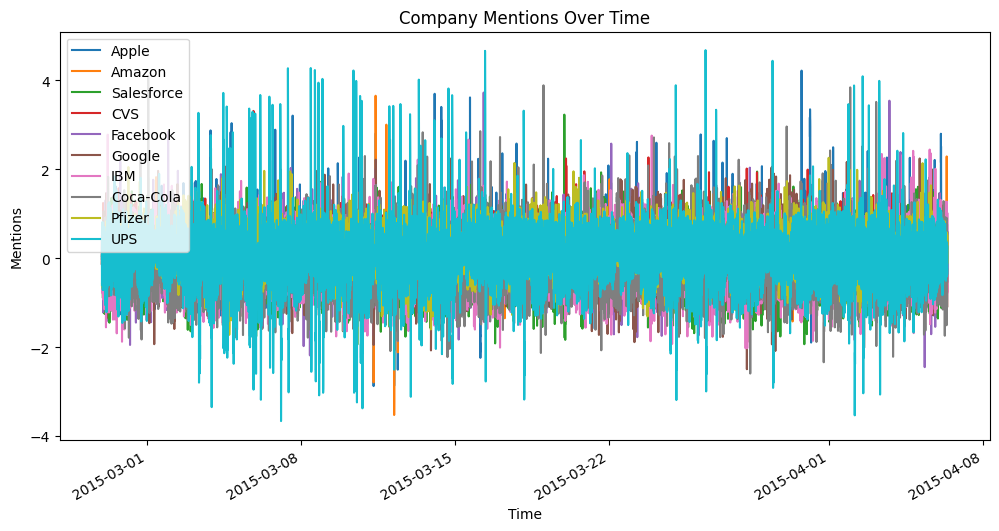

In [639]:
import matplotlib.pyplot as plt

train_scaled.plot(figsize=(12,6))
plt.title("Company Mentions Over Time")
plt.xlabel("Time")
plt.ylabel("Mentions")
plt.show()

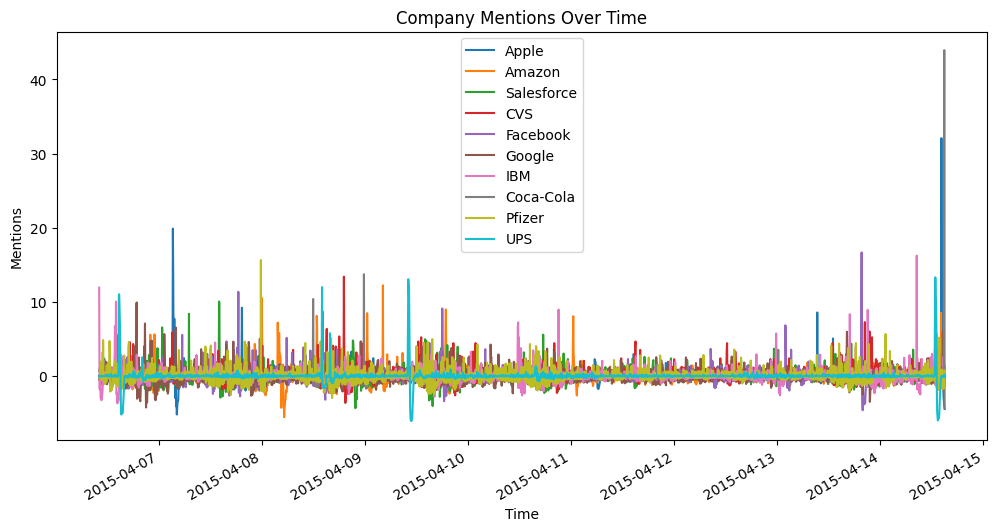

In [163]:
val_scaled.plot(figsize=(12,6))
plt.title("Company Mentions Over Time")
plt.xlabel("Time")
plt.ylabel("Mentions")
plt.show()

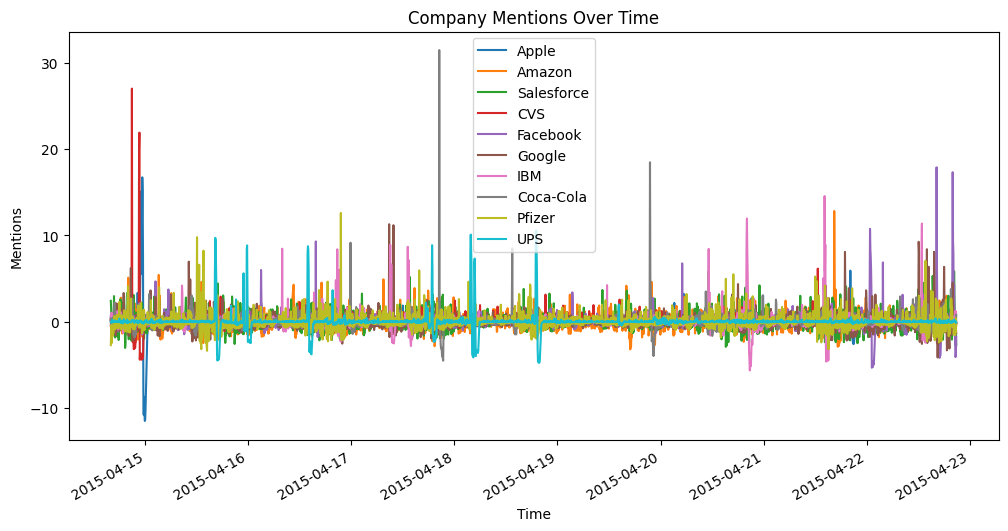

In [164]:
test_scaled.plot(figsize=(12,6))
plt.title("Company Mentions Over Time")
plt.xlabel("Time")
plt.ylabel("Mentions")
plt.show()

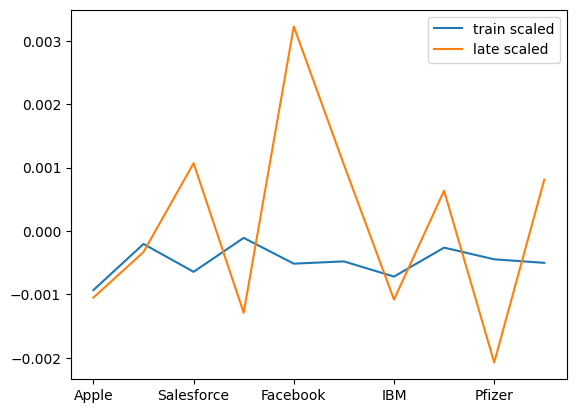

In [640]:
import matplotlib.pyplot as plt

train_scaled.mean().plot(label="train scaled")
test_scaled.mean().plot(label="late scaled")
plt.legend()

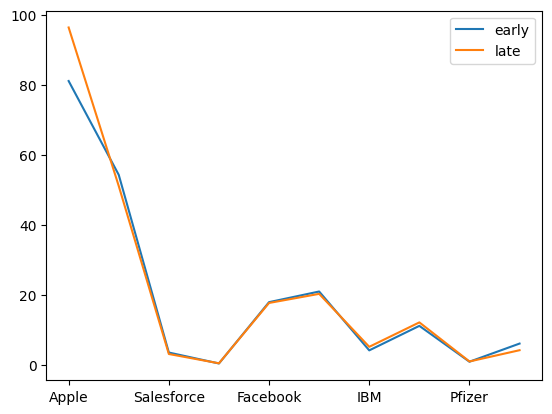

In [13]:
df.iloc[:train_end].mean().plot(label="early")
df.iloc[train_end:].mean().plot(label="late")
plt.legend()

In [14]:
import torch
import torch.nn as nn
import torch.nn.functional as F

In [728]:
def create_dataset(X, time_steps=12):
    Xs = []
    for i in range(len(X) - time_steps):
        v = X.iloc[i:(i + time_steps)].values
        Xs.append(v)
    return np.array(Xs)

In [1342]:
timestep = 6 #3 or above seems to do better

#can change this value for amounts in window so the int * 5 is how many minutes is in the window
#a lower value make it less aggresive in determining if anomaly, higher also makes it reconstruct poorly

X_train = create_dataset(train, time_steps=timestep)
X_val = create_dataset(val, time_steps=timestep)
X_test = create_dataset(test, time_steps=timestep)

In [1343]:
from torch.utils.data import TensorDataset, DataLoader

X_train_tensor = torch.tensor(X_train, dtype=torch.float32)

train_loader = DataLoader(
    TensorDataset(X_train_tensor),
    batch_size=64,
    shuffle=False
)

X_val_tensor = torch.tensor(X_val, dtype=torch.float32)

val_loader = DataLoader(
    TensorDataset(X_val_tensor),
    batch_size=64,
    shuffle=False
)

X_test_tensor = torch.tensor(X_test, dtype=torch.float32)

test_loader = DataLoader(
    TensorDataset(X_val_tensor),
    batch_size=64,
    shuffle=False
)

## Experimental LSTM autoencoder (no vae)

## This performs better at reconstruction

In [1344]:
import torch
import torch.nn as nn


class Encoder(nn.Module):

    def __init__(self, n_features, hidden_dim, latent_dim):

        super().__init__()

        self.lstm = nn.LSTM(
            input_size=n_features,
            hidden_size=hidden_dim,
            batch_first=True
        )

        self.fc = nn.Linear(hidden_dim, latent_dim)

    def forward(self, x):

        _, (hidden, _) = self.lstm(x)

        hidden = hidden[-1]

        latent = self.fc(hidden)

        return latent


class Decoder(nn.Module):

    def __init__(self, latent_dim, hidden_dim, seq_len, n_features):

        super().__init__()

        self.seq_len = seq_len
        self.hidden_dim = hidden_dim

        self.fc = nn.Linear(latent_dim, hidden_dim)

        self.lstm = nn.LSTM(
            input_size=hidden_dim,
            hidden_size=hidden_dim,
            batch_first=True
        )

        self.output_layer = nn.Sequential( #to get rid of negative values
            nn.Linear(hidden_dim, n_features),
            nn.Softplus()
            )

    def forward(self, z):

        hidden = self.fc(z)

        repeated = hidden.unsqueeze(1).repeat(1, self.seq_len, 1)

        decoded, _ = self.lstm(repeated)

        reconstruction = self.output_layer(decoded)

        return reconstruction


class LSTMAutoencoder(nn.Module):

    def __init__(
        self,
        n_features,
        seq_len,
        hidden_dim=256,
        latent_dim=64
    ):

        super().__init__()

        self.encoder = Encoder(
            n_features,
            hidden_dim,
            latent_dim
        )

        self.decoder = Decoder(
            latent_dim,
            hidden_dim,
            seq_len,
            n_features
        )

    def forward(self, x):

        z = self.encoder(x)

        reconstruction = self.decoder(z)

        return reconstruction

In [1345]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = LSTMAutoencoder(
    n_features=X_train.shape[2],
    seq_len=X_train.shape[1],
    hidden_dim=256,
    latent_dim=64
).to(device)

In [1346]:
criterion = nn.MSELoss()

In [ ]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

train_losses = []
val_losses = []

best_val = float("inf")

for epoch in range(300): #how many epochs


    model.train()

    train_total = 0

    for (x,) in train_loader:

        x = x.to(device)

        optimizer.zero_grad()

        reconstruction = model(x)

        loss = criterion(reconstruction, x)

        loss.backward()

        optimizer.step()

        train_total += loss.item()

    avg_train = train_total / len(train_loader)


    model.eval()

    val_total = 0

    with torch.no_grad():

        for (x,) in val_loader:

            x = x.to(device)

            reconstruction = model(x)

            loss = criterion(reconstruction, x)

            val_total += loss.item()

    avg_val = val_total / len(val_loader)

    train_losses.append(avg_train)
    val_losses.append(avg_val)

    # save best model
    if avg_val < best_val:

        best_val = avg_val

        torch.save(
            model.state_dict(),
            "best_lstm_autoencoder.pt"
        )

    print(
        f"Epoch {epoch}: "
        f"train={avg_train:.4f}, "
        f"val={avg_val:.4f}"
    )

Epoch 0: train=8773.1152, val=4805.8799
Epoch 1: train=8459.5733, val=4651.5258
Epoch 2: train=8356.2438, val=4585.0730
Epoch 3: train=8308.6740, val=4552.3649
Epoch 4: train=8286.8073, val=4537.3781
Epoch 5: train=8317.2143, val=4439.1615
Epoch 6: train=8123.8495, val=4354.0156
Epoch 7: train=8045.4813, val=4297.3834
Epoch 8: train=7983.9232, val=4249.8419
Epoch 9: train=7929.4759, val=4208.1866
Epoch 10: train=7880.3485, val=4170.1424
Epoch 11: train=7833.3479, val=4136.3642
Epoch 12: train=7791.0225, val=4099.7081
Epoch 13: train=7748.7370, val=4067.7509
Epoch 14: train=7707.2953, val=4041.2502
Epoch 15: train=7669.3075, val=4013.8800
Epoch 16: train=7631.3851, val=3985.4583
Epoch 17: train=7594.4815, val=3960.0501
Epoch 18: train=7559.2449, val=3933.3767
Epoch 19: train=7528.6429, val=3924.0753
Epoch 20: train=7505.7794, val=3896.0599
Epoch 21: train=7482.1955, val=3883.3768
Epoch 22: train=7462.9584, val=3867.0691
Epoch 23: train=7426.5878, val=3843.8463
Epoch 24: train=7416.3590,

In [1348]:
model.load_state_dict(
    torch.load("best_lstm_autoencoder.pt")
)

model.eval()

C:\Users\agsto\AppData\Local\Temp\ipykernel_10492\3627818868.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  torch.load("best_lstm_autoencoder.pt")


LSTMAutoencoder(
  (encoder): Encoder(
    (lstm): LSTM(10, 256, batch_first=True)
    (fc): Linear(in_features=256, out_features=64, bias=True)
  )
  (decoder): Decoder(
    (fc): Linear(in_features=64, out_features=256, bias=True)
    (lstm): LSTM(256, 256, batch_first=True)
    (output_layer): Sequential(
      (0): Linear(in_features=256, out_features=10, bias=True)
      (1): Softplus(beta=1.0, threshold=20.0)
    )
  )
)

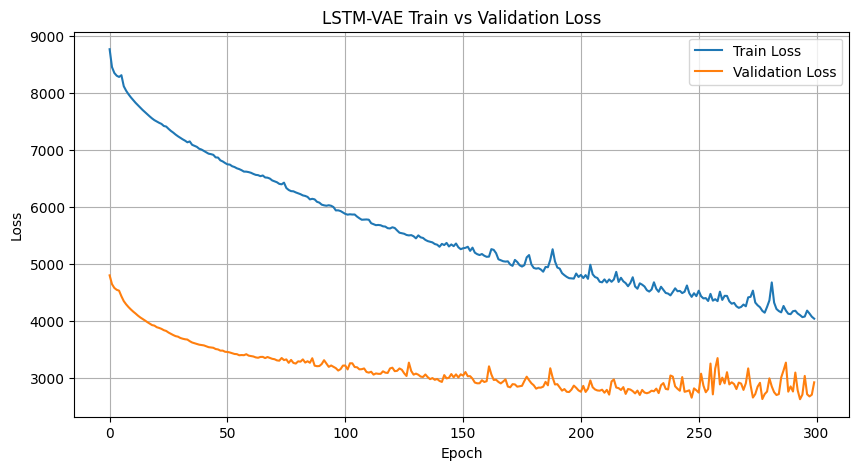

In [1349]:
plt.figure(figsize=(10, 5))

plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("LSTM-VAE Train vs Validation Loss")
plt.legend()
plt.grid(True)

plt.show()

In [1350]:
all_x = []
all_recon = []

with torch.no_grad():

    for (x,) in test_loader:

        x = x.to(device)

        reconstruction = model(x)

        all_x.append(x.cpu())
        all_recon.append(reconstruction.cpu())

x_test = torch.cat(all_x, dim=0)
x_recon = torch.cat(all_recon, dim=0)

## Company 

In [1371]:
company_idx = 1 #change this to see different companies

company_name = test.columns[company_idx]

In [1372]:
actual = x_test[:, :, company_idx].numpy()
reconstructed = x_recon[:, :, company_idx].numpy()

In [1373]:
actual_flat = actual[:, -1]
reconstructed_flat = reconstructed[:, -1]

error = (actual_flat - reconstructed_flat) ** 2

### IQR anomaly

In [1374]:
Q1 = np.percentile(error, 25)
Q3 = np.percentile(error, 75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

threshold = upper_bound

anomalies = error > threshold

threshold

np.float32(429.09912)

### percentile anomaly

In [1375]:
threshold = np.percentile(error, 99)

anomalies = error > threshold

threshold

np.float32(2582.14)

## SD anomaly

In [1376]:
threshold = error.mean() + 3 * error.std() #change int for how aggresive the threshold is

anomalies = error > threshold

threshold

np.float32(3461.3147)

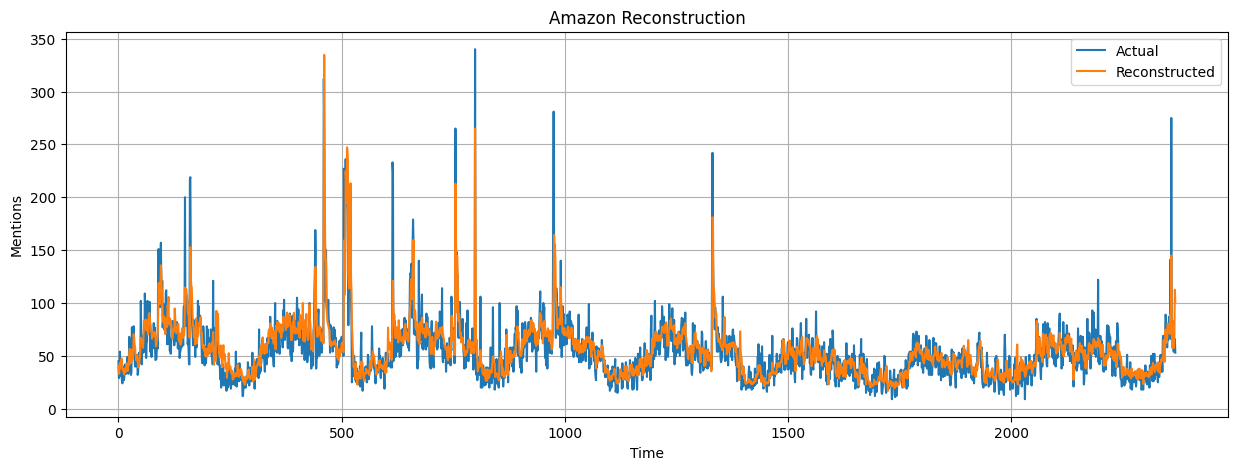

In [1377]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(15,5))

plt.plot(actual_flat, label="Actual")

plt.plot(
    reconstructed_flat,
    label="Reconstructed"
)

plt.title(f"{company_name} Reconstruction")

plt.xlabel("Time")
plt.ylabel("Mentions")

plt.legend()

plt.grid(True)

plt.show()

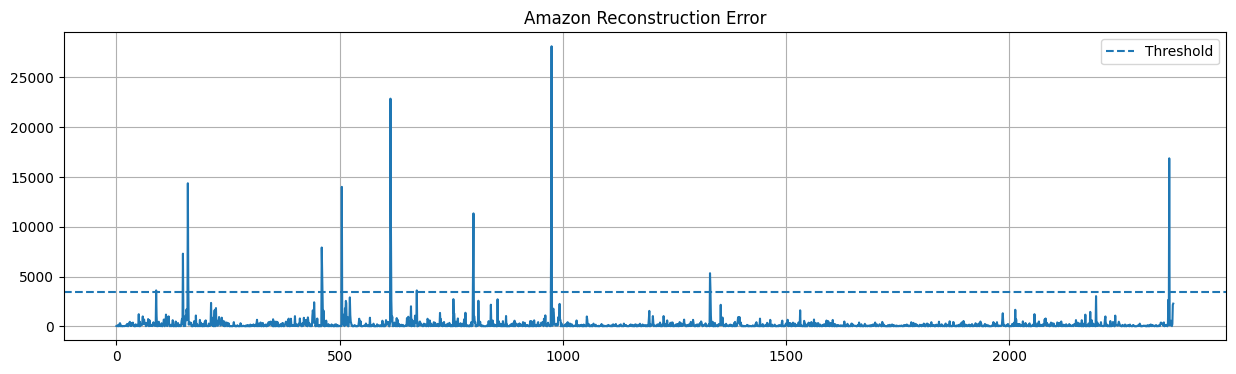

In [1378]:
plt.figure(figsize=(15,4))

plt.plot(error)

plt.axhline(
    threshold,
    linestyle='--',
    label='Threshold'
)

plt.title(f"{company_name} Reconstruction Error")

plt.legend()

plt.grid(True)

plt.show()

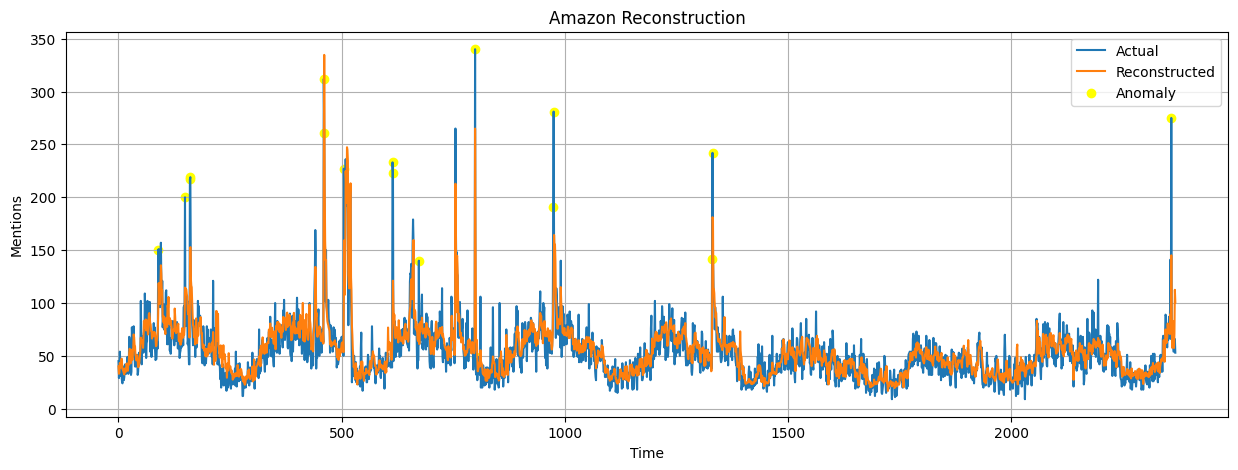

In [1379]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(15,5))

plt.plot(actual_flat, label="Actual")

plt.plot(
    reconstructed_flat,
    label="Reconstructed"
)

plt.scatter(
    np.where(anomalies)[0],
    actual_flat[anomalies],
    marker='o',
    label='Anomaly',
    color='yellow'
)

plt.title(f"{company_name} Reconstruction")

plt.xlabel("Time")
plt.ylabel("Mentions")

plt.legend()

plt.grid(True)

plt.show()

In [1381]:
np.sum(anomalies)

np.int64(17)

## DF wide anomaly detection

In [1382]:
reconstruction_error = (x_test - x_recon) ** 2

company_window_error = reconstruction_error.mean(dim=1)

company_mean = company_window_error.mean(dim=0)
company_std = company_window_error.std(dim=0)

recon_threshold = company_mean + 3* company_std 

company_anomalies = company_window_error > recon_threshold

simultaneous_count = company_anomalies.sum(dim=1)

major_events = simultaneous_count >= 3

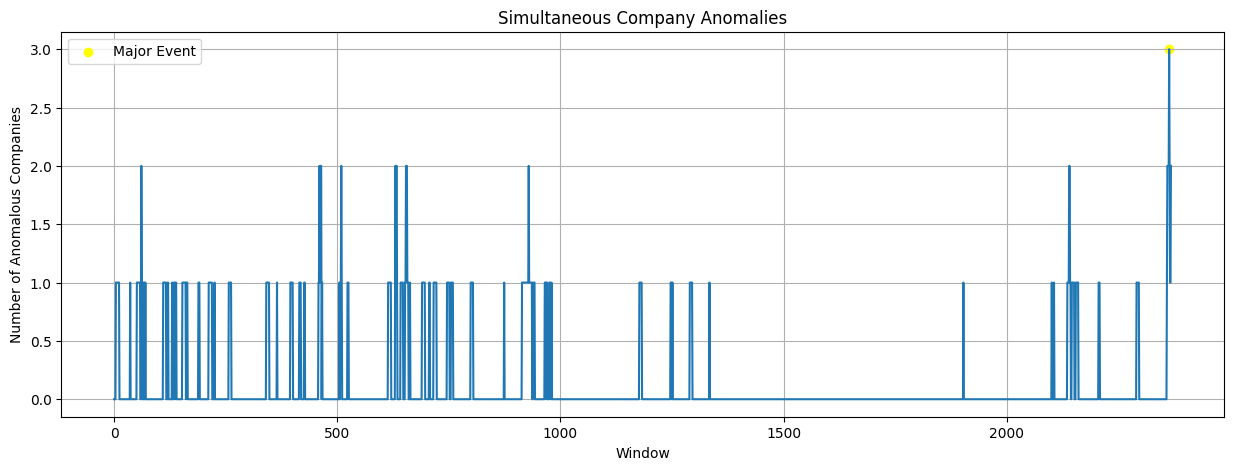

In [1383]:
count_np = simultaneous_count.cpu().numpy()
major_np = major_events.cpu().numpy()

plt.figure(figsize=(15,5))

plt.plot(count_np)

plt.scatter(
    np.where(major_np)[0],
    count_np[major_np],
    marker='o',
    label='Major Event',
    color='yellow'
)

plt.title("Simultaneous Company Anomalies")

plt.xlabel("Window")
plt.ylabel("Number of Anomalous Companies")

plt.legend()

plt.grid(True)

plt.show()

In [1384]:
actual_timeline = x_test[:, -1, :]
recon_timeline = x_recon[:, -1, :]

major_idx = np.where(
    major_events.cpu().numpy()
)[0]

In [1385]:
def plot_major_event(
    event_idx,
    actual,
    recon,
    columns,
    context=12
):

    start = max(0, event_idx - context)
    end = min(len(actual), event_idx + context)

    time = np.arange(start, end)

    n_companies = actual.shape[1]

    fig, axes = plt.subplots(
        n_companies,
        1,
        figsize=(15, 3*n_companies),
        sharex=True
    )

    if n_companies == 1:
        axes = [axes]

    for i in range(n_companies):

        axes[i].plot(
            time,
            actual[start:end, i],
            label="Actual"
        )

        axes[i].plot(
            time,
            recon[start:end, i],
            label="Reconstructed"
        )

        axes[i].axvline(
            event_idx,
            color='r',
            linestyle='--'
        )

        axes[i].set_title(columns[i])

        axes[i].legend()

        axes[i].grid(True)

    plt.xlabel("Time")

    plt.tight_layout()

    plt.show()

In [1386]:
actual_np = actual_timeline.cpu().numpy()
recon_np = recon_timeline.cpu().numpy()

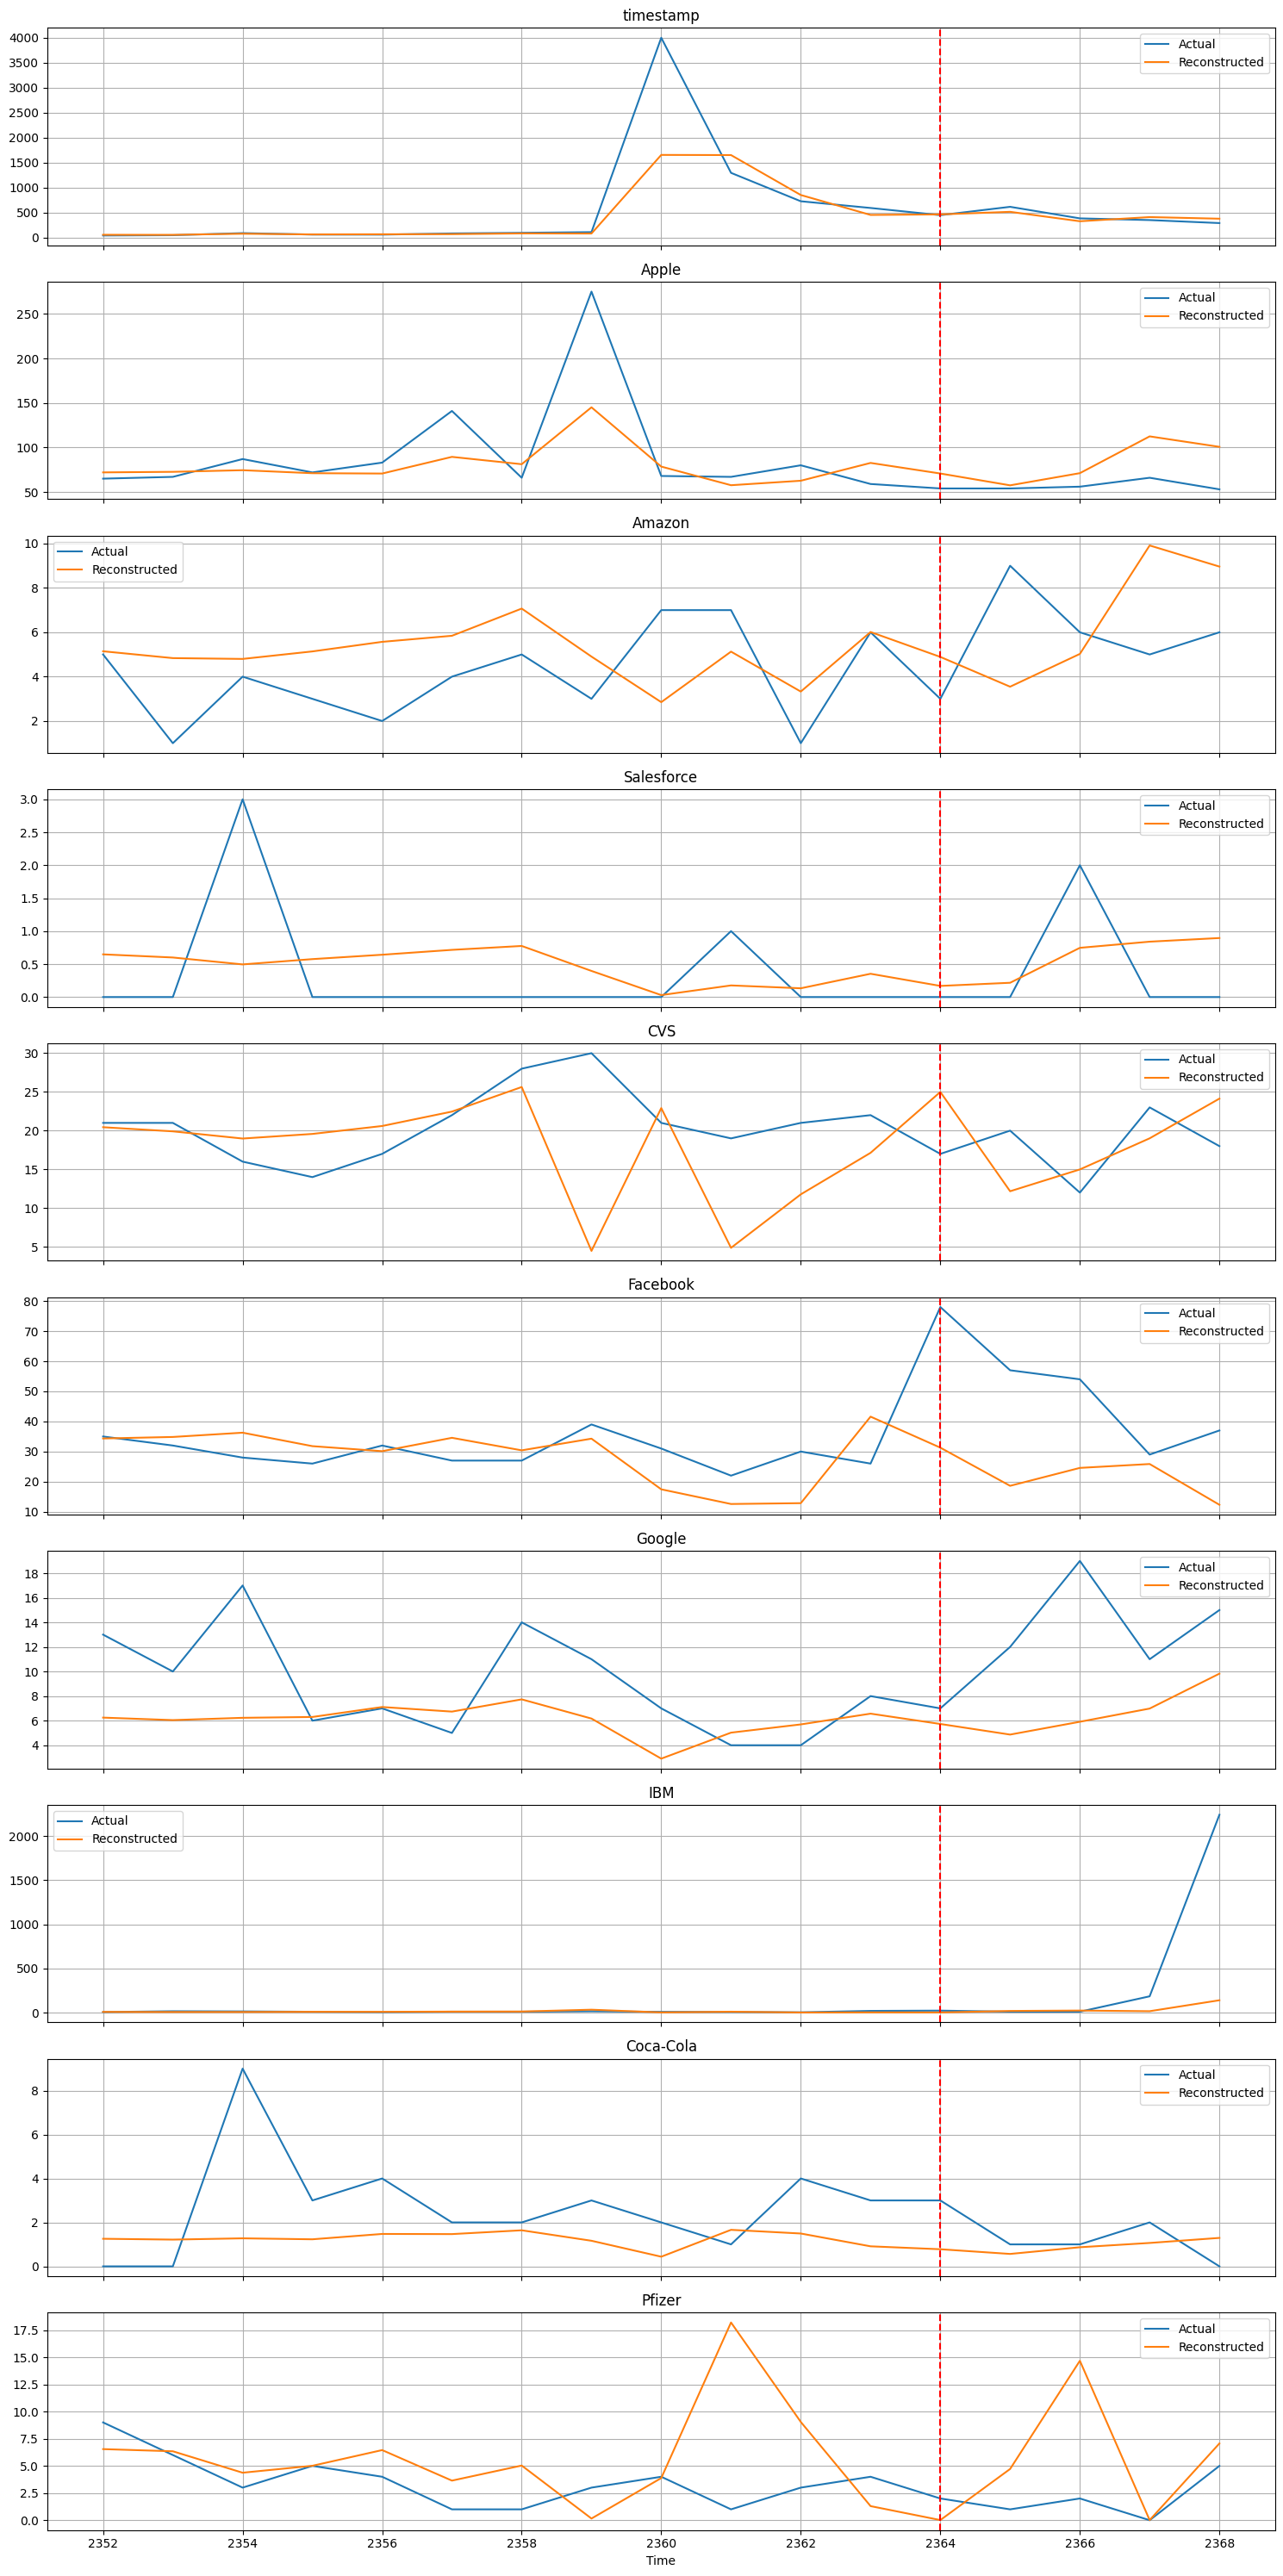

In [1390]:
plot_major_event(
    major_idx[0], #change int for different major event
    actual_np,
    recon_np,
    df.columns,
    context=12
)